In [3]:
# === Setup: librerie + caricamento dati ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Il CSV deve essere nella STESSA cartella di questo notebook
df = pd.read_csv("Lifestyle_data_Final_Project.csv")
df["class_date"] = pd.to_datetime(df["class_date"], format="%d-%m-%Y")
df["subscription_date"] = pd.to_datetime(df["subscription_date"], format="%d-%m-%Y")

print("Righe:", len(df), "| Utenti unici:", df["user_uuid"].nunique())
df.head()

Righe: 999 | Utenti unici: 240


,class_date,user_uuid,category,coach_id,language,level,challenge_id,country,subscription_date,platform,class_id,stars
0,2023-02-01,2,meditation,102,it,basic,3,it,2022-01-06,tv,2157,1
1,2023-05-22,241,power yoga,111,it,basic,1,it,2022-05-11,pc,6172,3
2,2022-08-06,173,power yoga,117,it,advanced,3,it,2021-12-12,pc,6255,2
3,2023-08-08,217,hatha,100,en,intermediate,3,uk,2022-02-07,tv,3317,4
4,2022-03-11,230,power yoga,113,fr,basic,2,fr,2020-01-09,pc,6159,1


In [4]:
# === Cella 2: costruzione tabella a livello utente (feature per il clustering) ===

# Flag: la pratica è dentro una challenge? (challenge_id 0 = pratica libera)
df["in_challenge"] = df["challenge_id"] > 0

# Funzione per prendere il valore più frequente (la "moda") di una colonna
def moda(s):
    return s.mode().iloc[0] if not s.mode().empty else np.nan

user = df.groupby("user_uuid").agg(
    n_pratiche      = ("class_id", "size"),          # quante pratiche totali
    quota_challenge = ("in_challenge", "mean"),      # % pratiche fatte in challenge
    n_coach_diversi = ("coach_id", "nunique"),       # varietà di coach seguiti
    categoria_top   = ("category", moda),            # categoria preferita
    livello_top     = ("level", moda),               # livello prevalente
    piattaforma_top = ("platform", moda),            # dispositivo prevalente
    paese           = ("country", moda),             # mercato
    iscrizione      = ("subscription_date", "first"),
    prima_pratica   = ("class_date", "min"),
    ultima_pratica  = ("class_date", "max"),
)

# Feature temporali derivate
user["mesi_attivita"]   = ((user["ultima_pratica"] - user["prima_pratica"]).dt.days / 30.44).round(1)
user["giorni_iscritto"] = (df["class_date"].max() - user["iscrizione"]).dt.days
user["quota_challenge"] = (user["quota_challenge"] * 100).round(0)

print("Tabella utente:", user.shape[0], "utenti ×", user.shape[1], "colonne")
user.head(8)

Tabella utente: 240 utenti × 12 colonne


,n_pratiche,quota_challenge,n_coach_diversi,categoria_top,livello_top,piattaforma_top,paese,iscrizione,prima_pratica,ultima_pratica,mesi_attivita,giorni_iscritto
user_uuid,,,,,,,,,,,,
1,7,71.0,6,power yoga,basic,tv,it,2021-05-20,2022-05-13,2023-11-18,18.2,952
2,6,83.0,4,power yoga,advanced,tv,it,2022-01-06,2023-01-10,2023-07-05,5.8,721
3,3,67.0,3,hatha,advanced,mobile,it,2020-07-22,2021-01-12,2021-07-16,6.1,1254
4,4,100.0,3,hatha,advanced,pc,fr,2022-05-10,2023-01-25,2023-07-10,5.5,597
5,4,25.0,3,power yoga,advanced,tv,uk,2022-01-25,2023-03-14,2023-12-26,9.4,702
6,2,100.0,2,hatha,advanced,tv,it,2020-09-14,2022-03-05,2022-09-01,5.9,1200
7,5,60.0,4,power yoga,basic,mobile,fr,2021-09-01,2022-02-22,2022-12-24,10.0,848
8,2,100.0,2,meditation,advanced,tv,fr,2022-04-23,2023-10-27,2023-12-05,1.3,614


C:\Users\Andrea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Andrea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Andrea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Andrea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

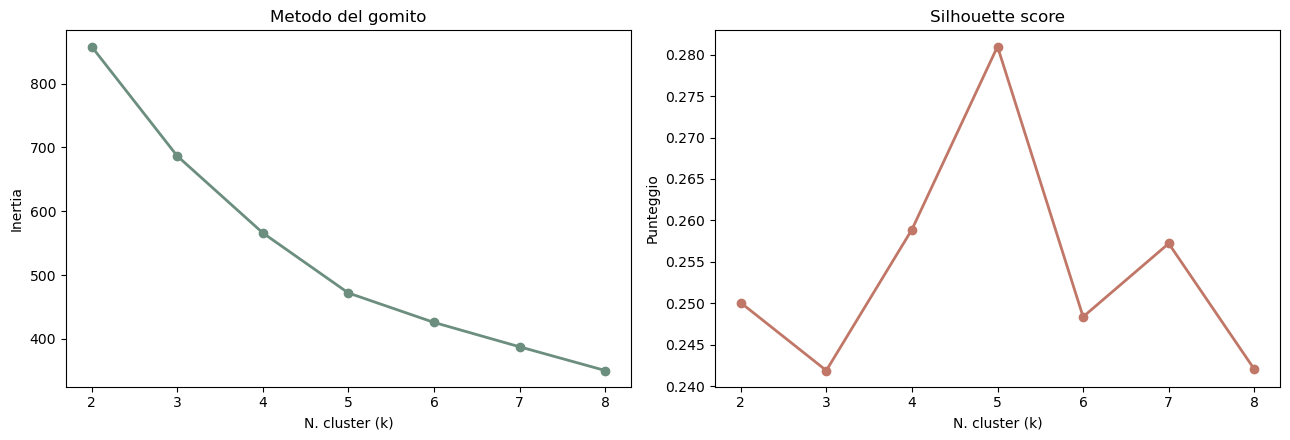

k=2: silhouette = 0.250
k=3: silhouette = 0.242
k=4: silhouette = 0.259
k=5: silhouette = 0.281
k=6: silhouette = 0.248
k=7: silhouette = 0.257
k=8: silhouette = 0.242


In [5]:
# === Cella 3: quante personas? Metodo del gomito + silhouette ===

# Usiamo solo le feature NUMERICHE comportamentali per il clustering
feature_num = ["n_pratiche", "quota_challenge", "n_coach_diversi", "mesi_attivita", "giorni_iscritto"]
X = user[feature_num].copy()

# Standardizziamo: mettiamo tutte le feature sulla stessa scala (media 0, dev.std 1)
# Serve perché 'giorni_iscritto' (centinaia) e 'n_pratiche' (unità) non sono confrontabili così come sono
X_scaled = StandardScaler().fit_transform(X)

# Proviamo da 2 a 8 cluster e misuriamo due indicatori
inertia, silhouette = [], []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)                              # "gomito": più basso = più compatti
    silhouette.append(silhouette_score(X_scaled, labels))   # più alto = cluster ben separati

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(K, inertia, "o-", color="#6B8E7F", lw=2)
axes[0].set_title("Metodo del gomito"); axes[0].set_xlabel("N. cluster (k)"); axes[0].set_ylabel("Inertia")
axes[1].plot(K, silhouette, "o-", color="#C17767", lw=2)
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("N. cluster (k)"); axes[1].set_ylabel("Punteggio")
plt.tight_layout(); plt.show()

for k, s in zip(K, silhouette):
    print(f"k={k}: silhouette = {s:.3f}")

In [6]:
# === Cella 4: clustering finale (k=5) e profilazione dei gruppi ===
k = 5
km = KMeans(n_clusters=k, random_state=42, n_init=10)
user["cluster"] = km.fit_predict(X_scaled)

# Quanti utenti in ogni cluster (occhio a gruppi troppo piccoli)
print("Utenti per cluster:")
print(user["cluster"].value_counts().sort_index(), "\n")

# Profilo NUMERICO medio di ciascun cluster -> è qui che nascono le personas
profilo_num = user.groupby("cluster")[feature_num].mean().round(1)
print("=== Profilo medio (comportamento) ===")
print(profilo_num, "\n")

# Profilo CATEGORICO: preferenza prevalente per cluster
profilo_cat = user.groupby("cluster")[["categoria_top","livello_top","piattaforma_top","paese"]].agg(moda)
print("=== Preferenze prevalenti ===")
print(profilo_cat)

C:\Users\Andrea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Utenti per cluster:
cluster
0    64
1    26
2    81
3    37
4    32
Name: count, dtype: int64 

=== Profilo medio (comportamento) ===
         n_pratiche  quota_challenge  n_coach_diversi  mesi_attivita  \
cluster                                                                
0               4.8             80.2              4.2            8.3   
1               7.7             73.3              6.8           19.9   
2               4.1             78.2              3.8           20.4   
3               2.6             39.8              2.4            7.8   
4               1.9            100.0              1.8            4.0   

         giorni_iscritto  
cluster                   
0                  603.7  
1                 1005.1  
2                 1161.4  
3                  890.7  
4                  862.5   

=== Preferenze prevalenti ===
        categoria_top livello_top piattaforma_top paese
cluster                                                
0          power yoga    adv

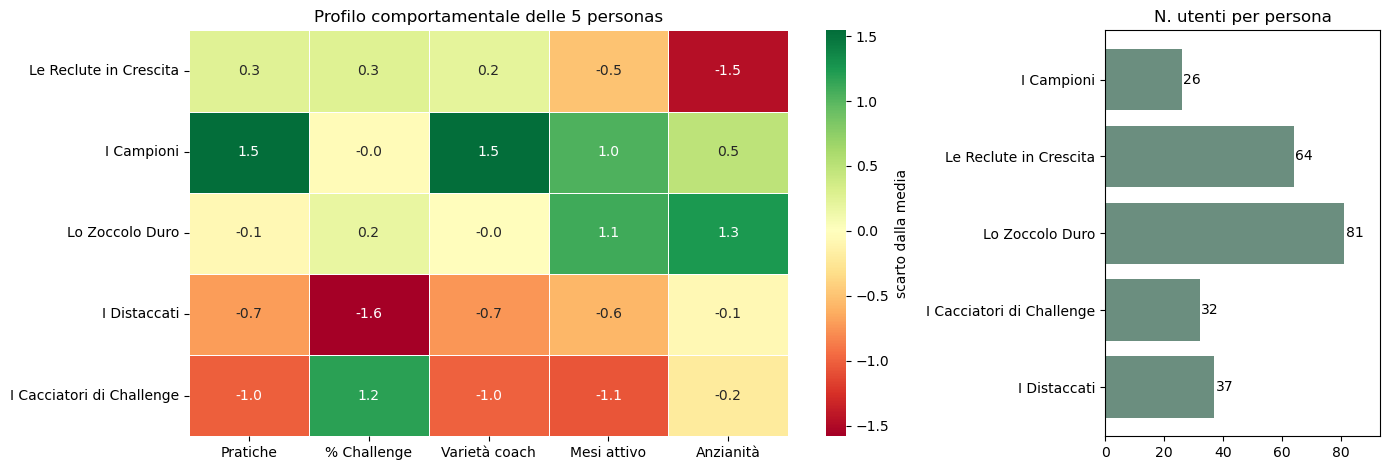

Salvato: utenti_con_persona.csv


In [7]:
# === Cella 5: nomi delle personas + heatmap dei profili ===

# Nomi proposti (cambiabili quando vuoi)
nomi_persona = {
    1: "I Campioni",
    0: "Le Reclute in Crescita",
    2: "Lo Zoccolo Duro",
    4: "I Cacciatori di Challenge",
    3: "I Distaccati",
}
user["persona"] = user["cluster"].map(nomi_persona)

# Heatmap: valori standardizzati (z-score) per far risaltare alto/basso RELATIVO tra gruppi
prof = user.groupby("cluster")[feature_num].mean()
prof_z = (prof - prof.mean()) / prof.std()
prof_z.index = [nomi_persona[i] for i in prof_z.index]
prof_z = prof_z.rename(columns={
    "n_pratiche":"Pratiche", "quota_challenge":"% Challenge",
    "n_coach_diversi":"Varietà coach", "mesi_attivita":"Mesi attivo", "giorni_iscritto":"Anzianità"
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios":[3, 1.1]})
sns.heatmap(prof_z, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=.5, cbar_kws={"label": "scarto dalla media"}, ax=ax1)
ax1.set_title("Profilo comportamentale delle 5 personas"); ax1.set_ylabel(""); ax1.set_xlabel("")

ordine = [1, 0, 2, 4, 3]
labels = [nomi_persona[i] for i in ordine]
sizes  = [int((user["cluster"] == i).sum()) for i in ordine]
ax2.barh(labels[::-1], sizes[::-1], color="#6B8E7F")
for i, v in enumerate(sizes[::-1]):
    ax2.text(v + 0.5, i, str(v), va="center")
ax2.set_title("N. utenti per persona"); ax2.margins(x=0.15)
plt.tight_layout(); plt.show()

# Salviamo la tabella etichettata per Tableau + documento personas
user.to_csv("utenti_con_persona.csv")
print("Salvato: utenti_con_persona.csv")

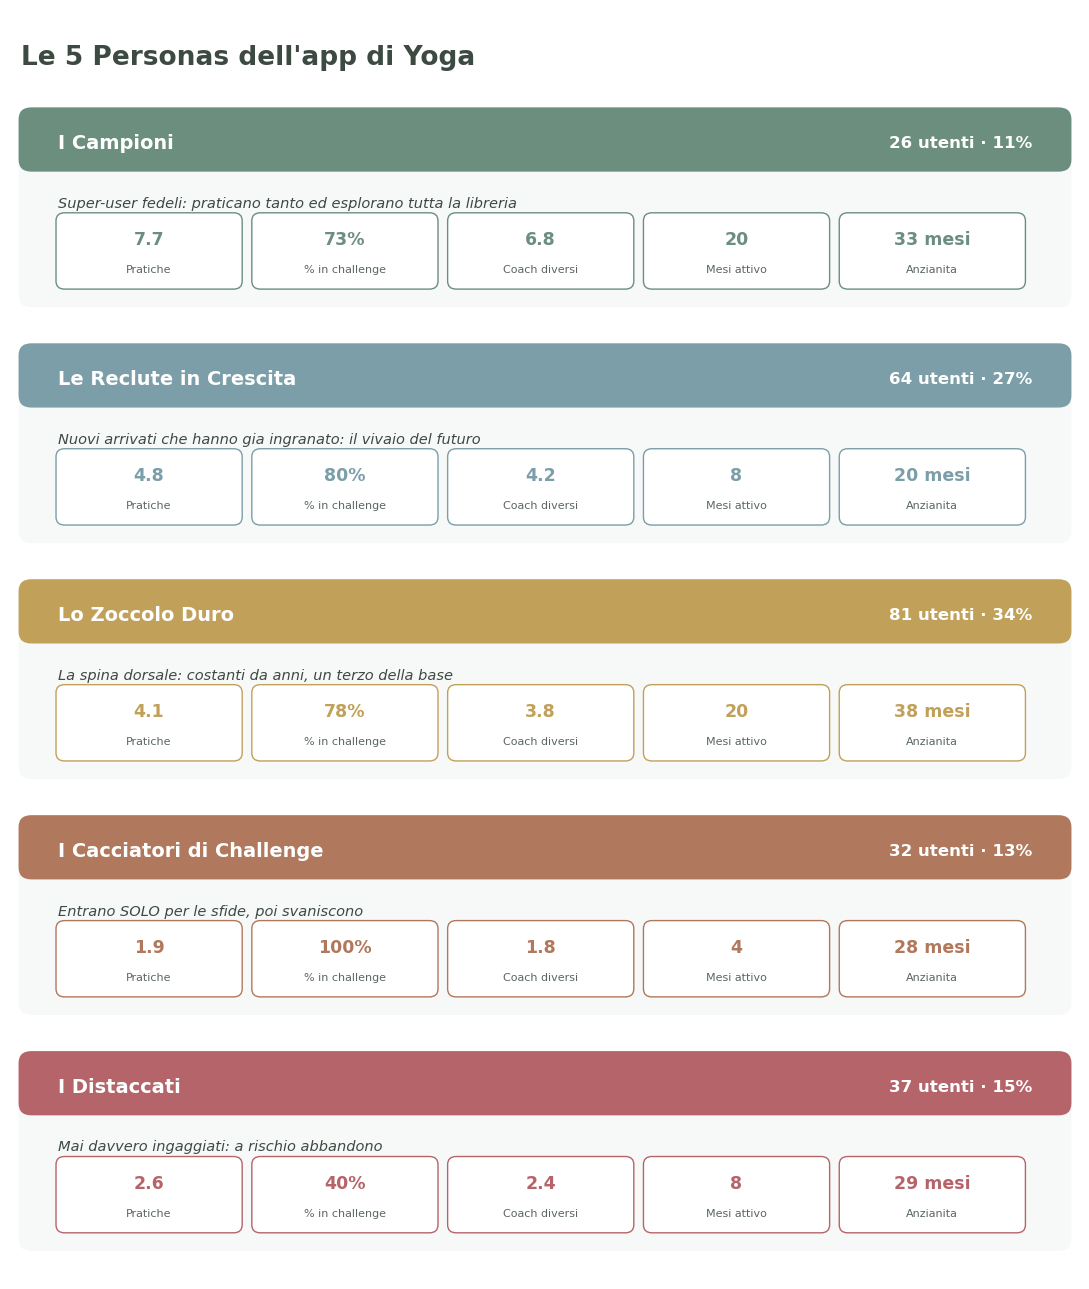

Immagine salvata: personas_board.png


In [8]:
# === Cella 6: board visiva delle 5 personas ===
from matplotlib.patches import FancyBboxPatch

tot = len(user)
nomi = {1:"I Campioni", 0:"Le Reclute in Crescita", 2:"Lo Zoccolo Duro",
        4:"I Cacciatori di Challenge", 3:"I Distaccati"}
colori = {1:"#6B8E7F", 0:"#7B9EA8", 2:"#C1A15A", 4:"#B0785C", 3:"#B5646A"}
tagline = {
 1:"Super-user fedeli: praticano tanto ed esplorano tutta la libreria",
 0:"Nuovi arrivati che hanno gia ingranato: il vivaio del futuro",
 2:"La spina dorsale: costanti da anni, un terzo della base",
 4:"Entrano SOLO per le sfide, poi svaniscono",
 3:"Mai davvero ingaggiati: a rischio abbandono",
}
ordine = [1, 0, 2, 4, 3]
prof = user.groupby("cluster")[["n_pratiche","quota_challenge","n_coach_diversi","mesi_attivita","giorni_iscritto"]].mean()

fig, ax = plt.subplots(figsize=(11, 13))
top = len(ordine)*2.35
ax.set_xlim(0, 10); ax.set_ylim(0, top+0.9); ax.axis("off")
ax.text(0.1, top+0.35, "Le 5 Personas dell'app di Yoga", fontsize=19, fontweight="bold", color="#3D4A42")

y = top - 2.05
for c in ordine:
    n = int((user["cluster"]==c).sum()); pct = n/tot*100; col = colori[c]
    ax.add_patch(FancyBboxPatch((0.1,y),9.8,1.95,boxstyle="round,pad=0.02,rounding_size=0.12",lw=0,facecolor="#F7F9F8",zorder=1))
    ax.add_patch(FancyBboxPatch((0.1,y+1.35),9.8,0.6,boxstyle="round,pad=0.02,rounding_size=0.12",lw=0,facecolor=col,zorder=2))
    ax.text(0.45,y+1.62,nomi[c],fontsize=14,fontweight="bold",color="white",va="center",zorder=3)
    ax.text(9.55,y+1.62,f"{n} utenti · {pct:.0f}%",fontsize=12,fontweight="bold",color="white",va="center",ha="right",zorder=3)
    ax.text(0.45,y+1.02,tagline[c],fontsize=10.5,style="italic",color="#3D4A42",va="center",zorder=3)
    p = prof.loc[c]
    chips = [("Pratiche",f"{p['n_pratiche']:.1f}"),("% in challenge",f"{p['quota_challenge']:.0f}%"),
             ("Coach diversi",f"{p['n_coach_diversi']:.1f}"),("Mesi attivo",f"{p['mesi_attivita']:.0f}"),
             ("Anzianita",f"{p['giorni_iscritto']/30.44:.0f} mesi")]
    cx = 0.45
    for lab,val in chips:
        w = 1.83
        ax.add_patch(FancyBboxPatch((cx,y+0.18),w-0.13,0.72,boxstyle="round,pad=0.02,rounding_size=0.08",lw=1,edgecolor=col,facecolor="white",zorder=3))
        ax.text(cx+(w-0.13)/2,y+0.66,val,fontsize=12.5,fontweight="bold",color=col,ha="center",va="center",zorder=4)
        ax.text(cx+(w-0.13)/2,y+0.36,lab,fontsize=8,color="#5A6660",ha="center",va="center",zorder=4)
        cx += w
    y -= 2.35

plt.tight_layout()
plt.savefig("personas_board.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Immagine salvata: personas_board.png")

## 👑 I Campioni — 26 utenti (11%)
**Chi sono.** I super-utilizzatori: 7.7 pratiche a testa, esplorano in media ~7 coach diversi, fedeli da oltre 2 anni. Sono i tuoi ambassador naturali.
**Cosa gli serve.** Contenuti nuovi e avanzati con continuità, sfide difficili, riconoscimento e senso di status.
**Leva strategica.** Programma **ambassador/referral** + badge e livelli. Dato che l'acquisizione è piatta, sono il canale di crescita più economico: trasformarli in reclutatori.

## 🌱 Le Reclute in Crescita — 64 utenti (27%)
**Chi sono.** I più recenti (iscritti da ~20 mesi) ma già molto attivi (4.8 pratiche, 80% in challenge). Sono in piena fase di formazione dell'abitudine.
**Cosa gli serve.** Onboarding guidato, prime challenge accessibili, rinforzo nelle settimane critiche per non abbandonare.
**Leva strategica.** **Onboarding strutturato + challenge "starter"**. Sono il vivaio da cui usciranno i futuri Campioni e Zoccolo Duro: proteggerli è proteggere la crescita.

## 🛡️ Lo Zoccolo Duro — 81 utenti (34%)
**Chi sono.** Il gruppo più numeroso e i più anziani (iscritti da ~38 mesi), attivi da 20 mesi ma con volume medio (4.1 pratiche). La spina dorsale silenziosa.
**Cosa gli serve.** Routine affidabile e un motivo per non spegnersi; varietà per non annoiarsi.
**Leva strategica.** La retention è già ottima: qui si lavora sulla **frequenza**. Essendo 1/3 della base, anche +1 pratica/mese a testa muove enormemente i numeri totali.

## 🎯 I Cacciatori di Challenge — 32 utenti (13%)
**Chi sono.** Entrano **esclusivamente per le sfide** (100% challenge!) ma con pochissimo volume (1.9 pratiche) e attivi solo ~4 mesi. Guidati dall'obiettivo, non dall'abitudine.
**Cosa gli serve.** Obiettivi chiari e gratificazione; manca l'aggancio alla pratica quotidiana *tra* una challenge e l'altra.
**Leva strategica.** **Challenge concatenate** (finita una, ne parte subito un'altra) + contenuti "ponte". Convertirli da cacciatori occasionali a praticanti continuativi.

## 💤 I Distaccati — 37 utenti (15%)
**Chi sono.** Bassi su tutto e — unici — freddi sulle challenge (40% contro il 73–100% degli altri). A rischio abbandono: il motore che ingaggia tutti gli altri, su di loro non ha fatto presa.
**Cosa gli serve.** Un motivo per tornare e riscoprire il valore dell'app.
**Leva strategica.** **Campagna di riattivazione (win-back)** inserendoli in una challenge soft, dato che è la leva che funziona. E capire *perché* non ha agganciato: è il segnale d'allarme da monitorare.